# P1 · Elementwise operations and broadcasting

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.6 · Elementwise operations and broadcasting

Broadcasting aligns trailing axes; compatible lengths are equal or one. Meaning must match as well as size.

**Prerequisites:** Reshape without losing meaning

**Predict:** Which bias shape adds a separate offset to each token in [2,3]?

**Mental model:** A linear layer adds one bias per output feature to every token vector. Writing an explicit loop over all tokens would repeat the same instruction.

### Why this operation exists

A linear layer adds one bias per output feature to every token vector. Writing an explicit loop over all tokens would repeat the same instruction.

Broadcasting lets a smaller tensor participate in an elementwise operation by aligning its trailing axes with the larger tensor.

Equal lengths match directly. A length-one axis can expand across the corresponding axis, and missing leading axes act like length one.

Valid broadcasting does not prove that the operation matches your intention. A token offset and a feature bias can require different singleton axes.

Name the axes first, then inspect the sizes. This prevents errors that produce plausible-looking values without raising an exception.

### Follow the values

The input has two token vectors, each with three features. The values zero through five identify which entries receive an addition.

The feature bias contains ten, twenty and thirty. Its three-entry axis aligns with the final feature axis of the input.

Adding it gives ten, twenty-one and thirty-two for the first token; thirteen, twenty-four and thirty-five for the second. The same feature bias is reused.

A token offset instead has shape two by one, with offsets 100 and 200. Its singleton feature axis expands across all three features.

The resulting vectors receive different common offsets. Double the feature bias in the experiment and compare which output changes; the separate token-offset operation stays fixed.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.arange(6, dtype=torch.float32).reshape(2,3)
show("Two token vectors", x)
bias = torch.tensor([10.,20.,30.]) * (2 if change else 1)
show("Feature bias [3]", bias)
show("Bias shared over tokens", x + bias)
offset = torch.tensor([[100.],[200.]])
show("Token offset [2,1]", offset)
show("Offset shared over features", x + offset)

Two token vectors: [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0]]
  shape [2, 3] · torch.float32 · cpu
Feature bias [3]: [10.0, 20.0, 30.0]
  shape [3] · torch.float32 · cpu
Bias shared over tokens: [[10.0, 21.0, 32.0], [13.0, 24.0, 35.0]]
  shape [2, 3] · torch.float32 · cpu
Token offset [2,1]: [[100.0], [200.0]]
  shape [2, 1] · torch.float32 · cpu
Offset shared over features: [[100.0, 101.0, 102.0], [203.0, 204.0, 205.0]]
  shape [2, 3] · torch.float32 · cpu


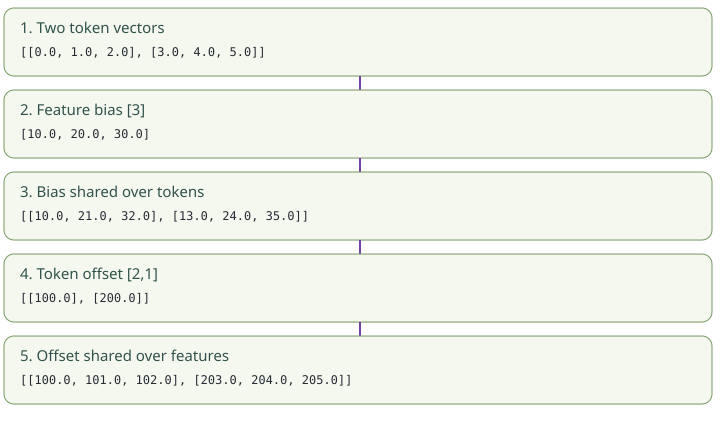

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

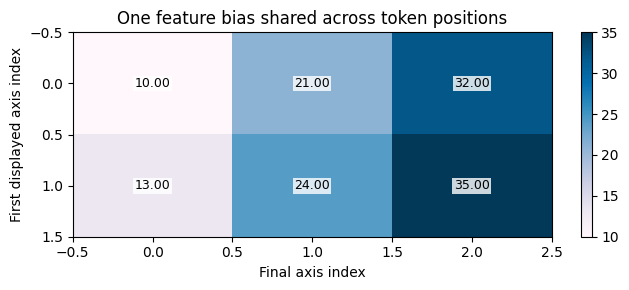

In [5]:
image = (x + bias).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('One feature bias shared across token positions'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

Read the shapes from right to left before applying plus or elementwise multiplication. Every aligned pair must match or contain a one.

Add a singleton axis when it expresses the intended sharing. Unsqueezing the wrong axis can either fail or silently apply an offset to the wrong axis.

A broadcast operation does not imply that a smaller tensor was learned separately at every expanded position. Shared parameters remain shared.

In-place operations have additional constraints: the destination cannot expand itself to accommodate a larger broadcast result. Prefer clear out-of-place expressions while learning.

Test an invalid shape and a misleading valid shape. Understanding both is more useful than memorizing one successful bias example.

### Change one thing

**Double the feature bias**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.arange(6, dtype=torch.float32).reshape(2,3)
show("Two token vectors", x)
bias = torch.tensor([10.,20.,30.]) * (2 if change else 1)
show("Feature bias [3]", bias)
show("Bias shared over tokens", x + bias)
offset = torch.tensor([[100.],[200.]])
show("Token offset [2,1]", offset)
show("Offset shared over features", x + offset)

Two token vectors: [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0]]
  shape [2, 3] · torch.float32 · cpu
Feature bias [3]: [20.0, 40.0, 60.0]
  shape [3] · torch.float32 · cpu
Bias shared over tokens: [[20.0, 41.0, 62.0], [23.0, 44.0, 65.0]]
  shape [2, 3] · torch.float32 · cpu
Token offset [2,1]: [[100.0], [200.0]]
  shape [2, 1] · torch.float32 · cpu
Offset shared over features: [[100.0, 101.0, 102.0], [203.0, 204.0, 205.0]]
  shape [2, 3] · torch.float32 · cpu


### A useful distinction

A broadcast can be legal and still express the wrong axis meaning.

In [7]:
try:
    torch.zeros(2,3) + torch.zeros(2)
except RuntimeError:
    print("Trailing lengths 3 and 2 cannot broadcast.")
else:
    raise AssertionError("Expected incompatible shapes")

Trailing lengths 3 and 2 cannot broadcast.


### ✋ Your turn

Add a feature bias [10,20,30] to zeros shaped [2,3] and put the nested list in answer.

In [8]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[10,20,30],[10,20,30]], 'A broadcast can be legal and still express the wrong axis meaning.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [9]:
#@title Show a solution { display-mode: "form" }
answer = (torch.zeros(2,3) + torch.tensor([10,20,30])).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[10,20,30],[10,20,30]], 'A broadcast can be legal and still express the wrong axis meaning.'
    print("✓ right:", answer)

✓ right: [[10.0, 20.0, 30.0], [10.0, 20.0, 30.0]]


### Reconnect to the transformer

Token vectors have batch, time and feature axes. A position table lookup produces time by feature values that are shared across the batch axis.

A linear bias has one feature axis and is shared across batch and time. These are two distinct uses of the same broadcasting rules.

Attention's causal permission matrix can be shared across batches and heads by adding singleton leading axes. Its time axes still have specific query and key meanings.

Gradients from repeated uses of a shared parameter accumulate into its original shape. Broadcasting does not create independently learned copies.

Next, move in the other direction: reduce an axis into a sum, average or selected maximum.

```python
x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which bias shape adds a separate offset to each token in [2,3]?

<details><summary>Check your explanation</summary>

[2,1]. A broadcast can be legal and still express the wrong axis meaning.

</details>